# Notebook 11 — Z-Transform & Relationship to Laplace

X(z) = sum_{n=0}^inf x[n] z^{-n}

Relationship to Laplace: z = exp(s*Ts). Covered: forward/inverse Z, ROC, pole-zero plots, Laplace<->Z mapping, discrete LTI.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import warnings
warnings.filterwarnings('ignore')

class ZTransform:
    'Numerical Z-Transform: X(z) = sum x[n] z^{-n}'

    def __init__(self, N_max=256):
        self.N_max = N_max

    def forward(self, x_seq, z):
        x = np.asarray(x_seq, dtype=complex)
        n = np.arange(len(x))
        if np.isscalar(z):
            return np.sum(x * z**(-n))
        z = np.asarray(z)
        return np.sum(x[:,None] * np.power(z[None,:], -n[:,None]), axis=0)

    def forward_func(self, x_func, z, N=None):
        N = N or self.N_max
        x = np.array([x_func(k) for k in range(N)], dtype=complex)
        return self.forward(x, z)

    def inverse_contour(self, X_func, N, r=2.0, n_pts=512):
        'x[n] = (1/2pij) contour X(z)z^{n-1}dz'
        theta = np.linspace(0, 2*np.pi, n_pts, endpoint=False)
        z_c = r * np.exp(1j*theta)
        dz  = 1j * z_c * (2*np.pi / n_pts)
        x = np.zeros(N, dtype=complex)
        for n in range(N):
            x[n] = np.sum(X_func(z_c) * z_c**(n-1) * dz) / (2*np.pi*1j)
        return np.real(x)

    def pole_zero(self, num, den):
        return np.roots(num), np.roots(den)

    def freq_response(self, num, den, n_pts=512):
        omega = np.linspace(0, np.pi, n_pts)
        z = np.exp(1j*omega)
        H = np.polyval(num, z) / np.polyval(den, z)
        return omega, H

zt = ZTransform()
print('ZTransform initialised')


ZTransform initialised


In [2]:
# Analytic Z-transform pair verification
# x[n]          X(z)                 ROC
# u[n]          z/(z-1)              |z|>1
# a^n u[n]      z/(z-a)              |z|>|a|
# n u[n]        z/(z-1)^2            |z|>1
# cos(w0*n)u    z(z-cos w0)/(z^2-2z cos w0+1)
# sin(w0*n)u    z sin w0/(z^2-2z cos w0+1)

z_test = 2.0+0j
N_test = 32

pairs = [
    ('u[n]',           lambda n: 1.0 if n>=0 else 0,       lambda z: z/(z-1)),
    ('0.5^n u[n]',     lambda n: 0.5**n if n>=0 else 0,    lambda z: z/(z-0.5)),
    ('0.8^n u[n]',     lambda n: 0.8**n if n>=0 else 0,    lambda z: z/(z-0.8)),
    ('n u[n]',         lambda n: float(n) if n>=0 else 0,  lambda z: z/(z-1)**2),
    ('cos(pi/4 n)u',   lambda n: np.cos(np.pi/4*n) if n>=0 else 0,
                       lambda z: z*(z-np.cos(np.pi/4))/(z**2-2*z*np.cos(np.pi/4)+1)),
    ('sin(pi/4 n)u',   lambda n: np.sin(np.pi/4*n) if n>=0 else 0,
                       lambda z: z*np.sin(np.pi/4)/(z**2-2*z*np.cos(np.pi/4)+1)),
]

print(f'Verification at z={z_test}  (N={N_test} terms)')
print(f'{"x[n]":<20} {"Numerical":>12} {"Analytic":>12} {"Rel err":>10}')
print('-'*58)
for name, xf, Xf in pairs:
    num = zt.forward_func(xf, z_test, N=N_test)
    ana = Xf(z_test)
    rel = abs(num-ana)/(abs(ana)+1e-15)
    print(f'{name:<20} {num.real:>12.6f} {ana.real:>12.6f} {rel:>10.2e}')


Verification at z=(2+0j)  (N=32 terms)
x[n]                    Numerical     Analytic    Rel err
----------------------------------------------------------
u[n]                     2.000000     2.000000   2.33e-10
0.5^n u[n]               1.333333     1.333333   0.00e+00
0.8^n u[n]               1.666667     1.666667   1.84e-13
n u[n]                   2.000000     2.000000   7.68e-09
cos(pi/4 n)u             1.190744     1.190744   2.33e-10
sin(pi/4 n)u             0.651239     0.651239   2.33e-10


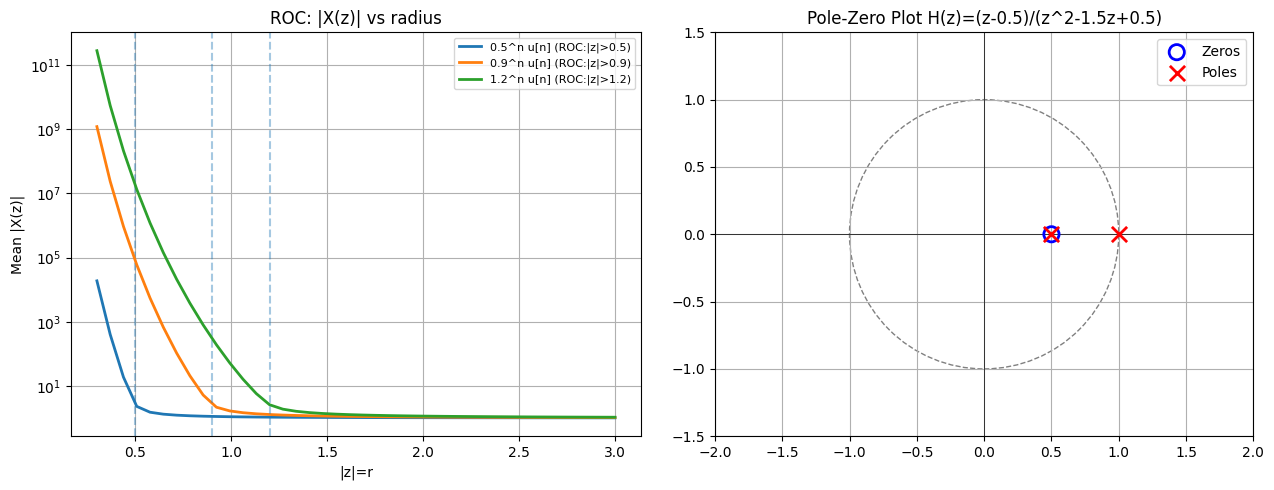

In [3]:
# ROC visualisation and pole-zero plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r_vals = np.linspace(0.3, 3.0, 40)
signals_roc = [
    ('0.5^n u[n] (ROC:|z|>0.5)', lambda n: 0.5**n if n>=0 else 0, 0.5),
    ('0.9^n u[n] (ROC:|z|>0.9)', lambda n: 0.9**n if n>=0 else 0, 0.9),
    ('1.2^n u[n] (ROC:|z|>1.2)', lambda n: 1.2**n if n>=0 else 0, 1.2),
]
for label, xf, a in signals_roc:
    mags = []
    for r in r_vals:
        theta = np.linspace(0, 2*np.pi, 40)
        zc = r*np.exp(1j*theta)
        Xz = np.array([zt.forward_func(xf, zv, N=20) for zv in zc])
        mags.append(np.mean(np.abs(Xz)))
    axes[0].semilogy(r_vals, mags, linewidth=2, label=label)
    axes[0].axvline(a, linestyle='--', alpha=0.4)

axes[0].set_xlabel('|z|=r'); axes[0].set_ylabel('Mean |X(z)|')
axes[0].set_title('ROC: |X(z)| vs radius')
axes[0].legend(fontsize=8); axes[0].grid(True)

# Pole-zero plot
num_pz = [1, -0.5]; den_pz = [1, -1.5, 0.5]
zeros, poles = zt.pole_zero(num_pz, den_pz)
circle = Circle((0,0), 1.0, fill=False, color='gray', linestyle='--', linewidth=1)
axes[1].add_patch(circle)
axes[1].scatter(zeros.real, zeros.imag, s=120, marker='o', facecolors='none',
                edgecolors='blue', linewidth=2, label='Zeros', zorder=5)
axes[1].scatter(poles.real, poles.imag, s=120, marker='x',
                color='red', linewidth=2, label='Poles', zorder=5)
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)
axes[1].set_xlim(-2,2); axes[1].set_ylim(-1.5,1.5)
axes[1].set_title('Pole-Zero Plot H(z)=(z-0.5)/(z^2-1.5z+0.5)')
axes[1].legend(); axes[1].grid(True); axes[1].set_aspect('equal')
plt.tight_layout(); plt.show()


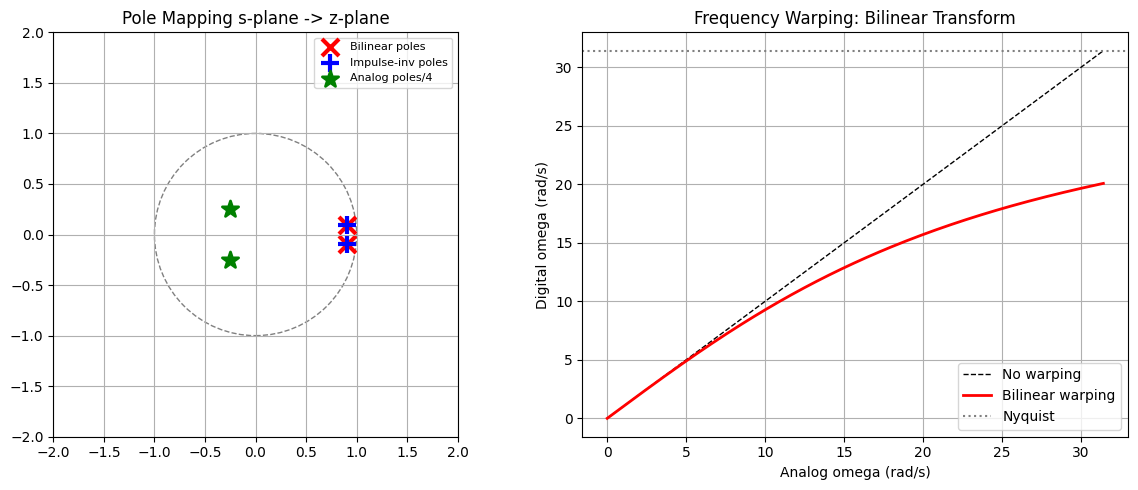

Bilinear z-poles: [0.90045249+0.09049774j 0.90045249-0.09049774j]
Impulse-inv z-poles: [0.900317+0.09033301j 0.900317-0.09033301j]


In [4]:
# Laplace <-> Z: Bilinear (Tustin) and Impulse-Invariant Mappings
Ts = 0.1

def bilinear_s_to_z(s_pts, Ts):
    return (1 + s_pts*Ts/2) / (1 - s_pts*Ts/2)

def impulse_invariant(s_pts, Ts):
    return np.exp(s_pts * Ts)

s_poles = np.array([-1+1j, -1-1j])  # 2nd-order Butterworth

z_bl = bilinear_s_to_z(s_poles, Ts)
z_ii = impulse_invariant(s_poles, Ts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
unit = Circle((0,0), 1.0, fill=False, color='gray', linestyle='--')
axes[0].add_patch(unit)
axes[0].scatter(z_bl.real, z_bl.imag, s=150, marker='x', color='red', lw=3, label='Bilinear poles')
axes[0].scatter(z_ii.real, z_ii.imag, s=150, marker='+', color='blue', lw=3, label='Impulse-inv poles')
axes[0].scatter(s_poles.real/4, s_poles.imag/4, s=150, marker='*', color='green', lw=2, label='Analog poles/4')
axes[0].set_xlim(-2,2); axes[0].set_ylim(-2,2)
axes[0].set_title('Pole Mapping s-plane -> z-plane')
axes[0].legend(fontsize=8); axes[0].grid(True); axes[0].set_aspect('equal')

omega_a = np.linspace(0, np.pi/Ts, 200)
omega_d = 2/Ts * np.arctan(omega_a*Ts/2)
axes[1].plot(omega_a, omega_a, 'k--', lw=1, label='No warping')
axes[1].plot(omega_a, omega_d, 'r-', lw=2, label='Bilinear warping')
axes[1].axhline(np.pi/Ts, color='gray', ls=':', label='Nyquist')
axes[1].set_xlabel('Analog omega (rad/s)'); axes[1].set_ylabel('Digital omega (rad/s)')
axes[1].set_title('Frequency Warping: Bilinear Transform')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()
print(f'Bilinear z-poles: {z_bl}')
print(f'Impulse-inv z-poles: {z_ii}')


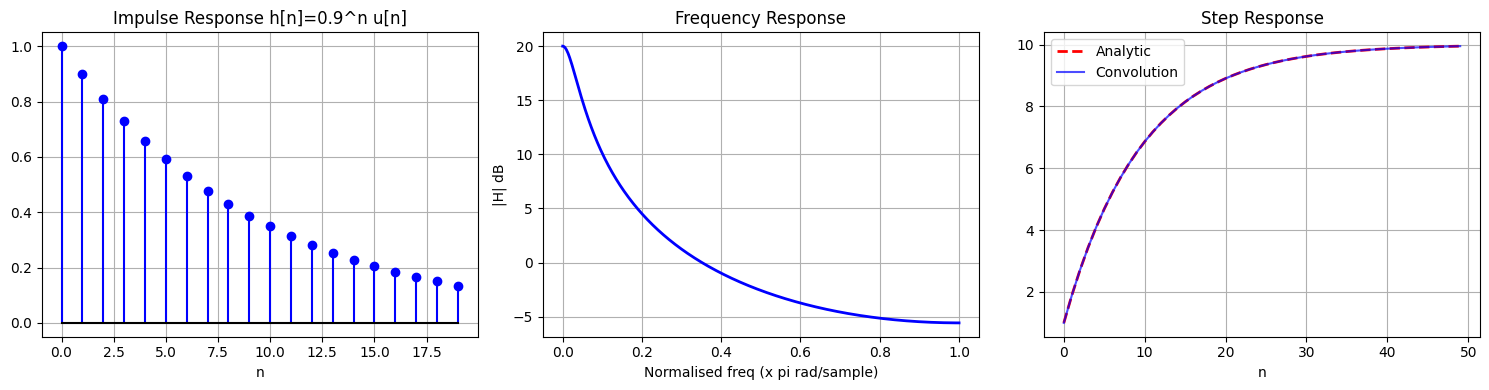

Steady-state gain = 1/(1-0.9) = 10.0
Max step error: 3.55e-15


In [5]:
# Discrete LTI System: y[n]-0.9*y[n-1]=x[n], H(z)=z/(z-0.9), h[n]=0.9^n u[n]
from scipy import signal as sp_signal

num_iir = [1, 0]; den_iir = [1, -0.9]
omega, H_freq = zt.freq_response(num_iir, den_iir)

N_resp = 50
n_arr = np.arange(N_resp)
h_n   = 0.9**n_arr
step  = np.convolve(h_n, np.ones(N_resp))[:N_resp]
step_ana = (1 - 0.9**(n_arr+1)) / 0.1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].stem(n_arr[:20], h_n[:20], markerfmt='bo', linefmt='b-', basefmt='k-')
axes[0].set_title('Impulse Response h[n]=0.9^n u[n]')
axes[0].set_xlabel('n'); axes[0].grid(True)

axes[1].plot(omega/np.pi, 20*np.log10(np.abs(H_freq)+1e-12), 'b-', lw=2)
axes[1].set_xlabel('Normalised freq (x pi rad/sample)')
axes[1].set_ylabel('|H| dB'); axes[1].set_title('Frequency Response')
axes[1].grid(True)

axes[2].plot(n_arr, step_ana, 'r--', lw=2, label='Analytic')
axes[2].plot(n_arr, step, 'b-', lw=1.5, alpha=0.7, label='Convolution')
axes[2].set_title('Step Response'); axes[2].set_xlabel('n')
axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()
print(f'Steady-state gain = 1/(1-0.9) = {1/(1-0.9):.1f}')
print(f'Max step error: {np.max(np.abs(step-step_ana)):.2e}')
